In [2]:
import os

print(os.path.getsize("/content/UCI HAR Dataset.zip"))

60999314


In [3]:
import zipfile

zip_path = "/content/UCI HAR Dataset.zip"

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall("/content/")

print("Dataset extracted successfully!")

Dataset extracted successfully!


In [4]:
import os

print(os.listdir("/content/UCI HAR Dataset"))

['activity_labels.txt', 'features.txt', 'test', '.DS_Store', 'features_info.txt', 'README.txt', 'train']


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries imported successfully!")

Libraries imported successfully!


In [6]:
features = pd.read_csv(
    "/content/UCI HAR Dataset/features.txt",
    sep=r"\s+",
    header=None,
    names=["index", "feature"]
)

features.head()

,index,feature
0,1,tBodyAcc-mean()-X
1,2,tBodyAcc-mean()-Y
2,3,tBodyAcc-mean()-Z
3,4,tBodyAcc-std()-X
4,5,tBodyAcc-std()-Y


In [7]:
print("Total Features:", len(features))
print("Unique Features:", features["feature"].nunique())

duplicates = features["feature"].duplicated().sum()

print("Duplicate Feature Names:", duplicates)

Total Features: 561
Unique Features: 477
Duplicate Feature Names: 84


In [8]:
X_train = pd.read_csv(
    "/content/UCI HAR Dataset/train/X_train.txt",
    sep=r"\s+",
    header=None
)

y_train = pd.read_csv(
    "/content/UCI HAR Dataset/train/y_train.txt",
    sep=r"\s+",
    header=None,
    names=["Activity"]
)

print("Training Features Shape:", X_train.shape)
print("Training Target Shape:", y_train.shape)

Training Features Shape: (7352, 561)
Training Target Shape: (7352, 1)


In [9]:
X_test = pd.read_csv(
    "/content/UCI HAR Dataset/test/X_test.txt",
    sep=r"\s+",
    header=None
)

y_test = pd.read_csv(
    "/content/UCI HAR Dataset/test/y_test.txt",
    sep=r"\s+",
    header=None,
    names=["Activity"]
)

print("Testing Features Shape:", X_test.shape)
print("Testing Target Shape:", y_test.shape)

Testing Features Shape: (2947, 561)
Testing Target Shape: (2947, 1)


In [10]:
X_train.columns = features["feature"].values
X_test.columns = features["feature"].values

print(X_train.shape)
print(X_test.shape)

(7352, 561)
(2947, 561)


In [11]:
activity_labels = pd.read_csv(
    "/content/UCI HAR Dataset/activity_labels.txt",
    sep=r"\s+",
    header=None,
    names=["Activity_ID", "Activity_Name"]
)

activity_labels

,Activity_ID,Activity_Name
0,1,WALKING
1,2,WALKING_UPSTAIRS
2,3,WALKING_DOWNSTAIRS
3,4,SITTING
4,5,STANDING
5,6,LAYING


In [12]:
activity_map = dict(
    zip(
        activity_labels["Activity_ID"],
        activity_labels["Activity_Name"]
    )
)

y_train["Activity_Name"] = y_train["Activity"].map(activity_map)
y_test["Activity_Name"] = y_test["Activity"].map(activity_map)

y_train.head()

,Activity,Activity_Name
0,5,STANDING
1,5,STANDING
2,5,STANDING
3,5,STANDING
4,5,STANDING


In [13]:
print("===== DATASET INFORMATION =====")

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])
print("Number of features:", X_train.shape[1])
print("Number of activities:", y_train["Activity"].nunique())

print("\nActivity Classes:")
print(y_train["Activity_Name"].unique())

===== DATASET INFORMATION =====
Training samples: 7352
Testing samples: 2947
Number of features: 561
Number of activities: 6

Activity Classes:
['STANDING' 'SITTING' 'LAYING' 'WALKING' 'WALKING_DOWNSTAIRS'
 'WALKING_UPSTAIRS']


In [14]:
print("Missing values in X_train:", X_train.isnull().sum().sum())
print("Missing values in X_test:", X_test.isnull().sum().sum())
print("Missing values in y_train:", y_train.isnull().sum().sum())
print("Missing values in y_test:", y_test.isnull().sum().sum())

Missing values in X_train: 0
Missing values in X_test: 0
Missing values in y_train: 0
Missing values in y_test: 0


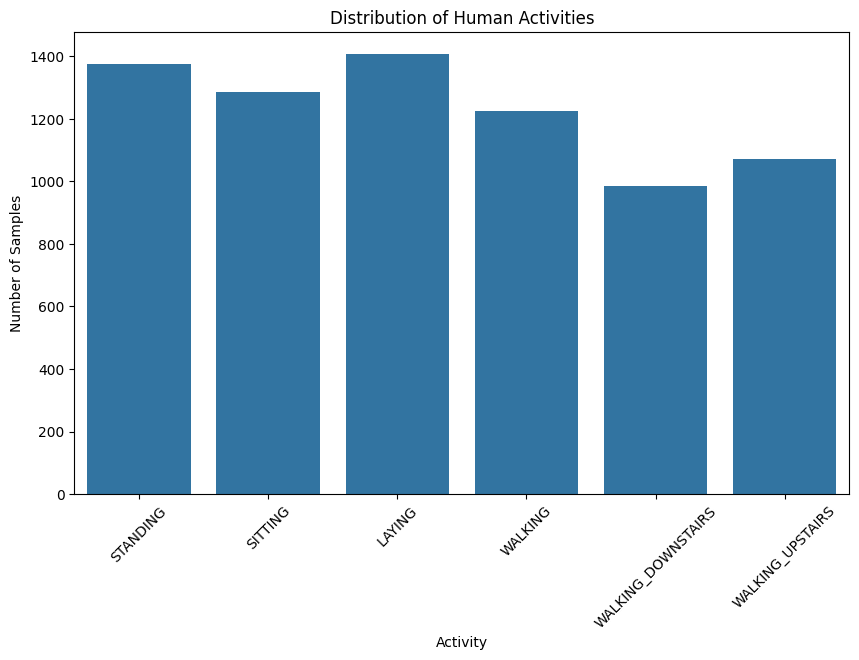

In [15]:
plt.figure(figsize=(10, 6))

sns.countplot(
    data=y_train,
    x="Activity_Name"
)

plt.title("Distribution of Human Activities")
plt.xlabel("Activity")
plt.ylabel("Number of Samples")
plt.xticks(rotation=45)

plt.show()

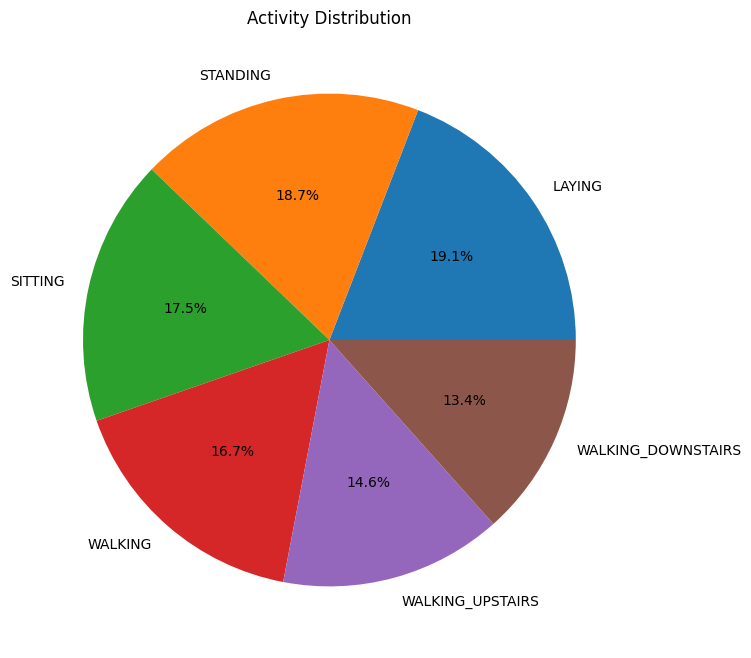

In [16]:
plt.figure(figsize=(8, 8))

y_train["Activity_Name"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%"
)

plt.title("Activity Distribution")

plt.ylabel("")

plt.show()

## Dataset Summary

The Human Activity Recognition dataset contains smartphone sensor measurements collected from 30 volunteers performing six different physical activities. The dataset contains 10,299 observations and 561 features extracted from accelerometer and gyroscope signals. The six activities include walking, walking upstairs, walking downstairs, sitting, standing, and laying. The training dataset contains 7,352 samples, while the test dataset contains 2,947 samples. The goal of this project is to build a machine learning classification model that can accurately recognize human activities based on sensor-derived features.

In [17]:
# Check for infinite values
print("Infinite values in training data:",
      np.isinf(X_train).sum().sum())

print("Infinite values in testing data:",
      np.isinf(X_test).sum().sum())

Infinite values in training data: 0
Infinite values in testing data: 0


In [18]:
# Check for duplicate rows
print("Duplicate rows in training data:", X_train.duplicated().sum())
print("Duplicate rows in testing data:", X_test.duplicated().sum())

Duplicate rows in training data: 0
Duplicate rows in testing data: 0


In [19]:
# Remove duplicate rows if any
X_train = X_train.drop_duplicates().reset_index(drop=True)
y_train = y_train.loc[X_train.index].reset_index(drop=True)

X_test = X_test.drop_duplicates().reset_index(drop=True)
y_test = y_test.loc[X_test.index].reset_index(drop=True)

print("Training shape after cleaning:", X_train.shape)
print("Testing shape after cleaning:", X_test.shape)

Training shape after cleaning: (7352, 561)
Testing shape after cleaning: (2947, 561)


In [20]:
# Feature Engineering

X_train_engineered = X_train.copy()
X_test_engineered = X_test.copy()

# Mean of all sensor features
X_train_engineered["sensor_mean"] = X_train.mean(axis=1)
X_test_engineered["sensor_mean"] = X_test.mean(axis=1)

# Standard deviation of all sensor features
X_train_engineered["sensor_std"] = X_train.std(axis=1)
X_test_engineered["sensor_std"] = X_test.std(axis=1)

print("Original number of features:", X_train.shape[1])
print("New number of features:", X_train_engineered.shape[1])

Original number of features: 561
New number of features: 563


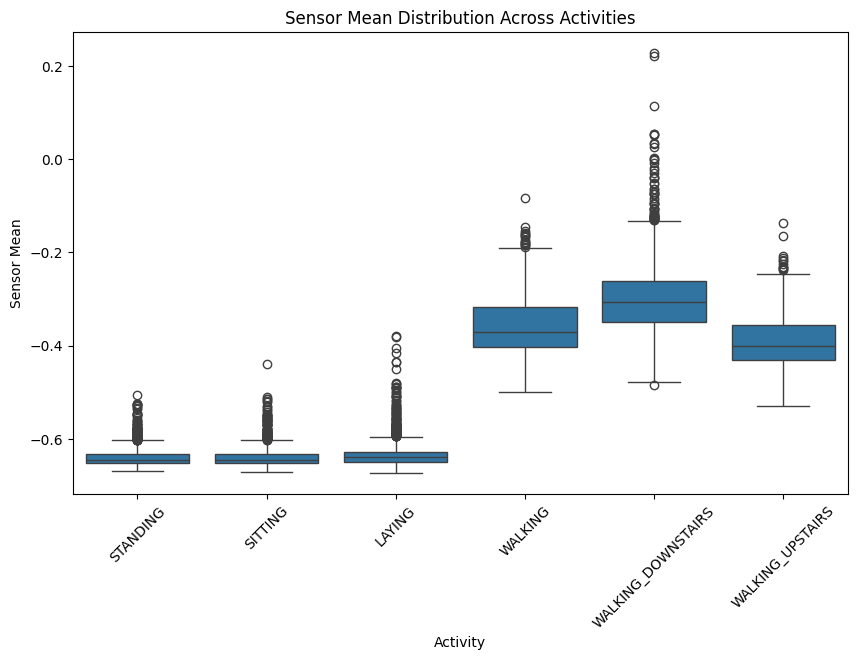

In [21]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=X_train_engineered,
    x=y_train["Activity_Name"],
    y="sensor_mean"
)

plt.title("Sensor Mean Distribution Across Activities")
plt.xlabel("Activity")
plt.ylabel("Sensor Mean")
plt.xticks(rotation=45)

plt.show()

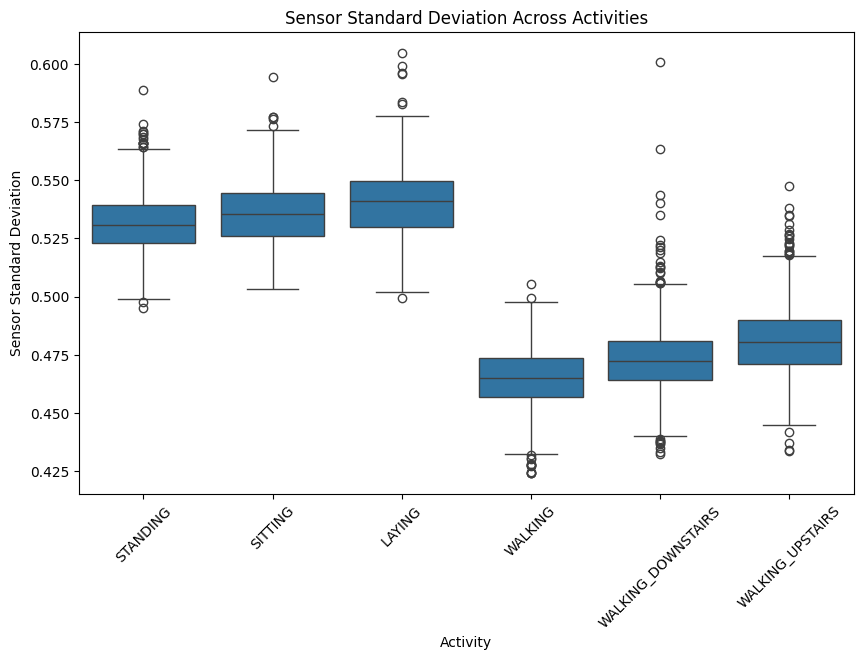

In [22]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=X_train_engineered,
    x=y_train["Activity_Name"],
    y="sensor_std"
)

plt.title("Sensor Standard Deviation Across Activities")
plt.xlabel("Activity")
plt.ylabel("Sensor Standard Deviation")
plt.xticks(rotation=45)

plt.show()

In [23]:
y_train_model = y_train["Activity"]
y_test_model = y_test["Activity"]

print("Training target shape:", y_train_model.shape)
print("Testing target shape:", y_test_model.shape)

Training target shape: (7352,)
Testing target shape: (2947,)


In [24]:
X_train_final = X_train_engineered.copy()
X_test_final = X_test_engineered.copy()

print("Final Training Data:", X_train_final.shape)
print("Final Testing Data:", X_test_final.shape)

Final Training Data: (7352, 563)
Final Testing Data: (2947, 563)


In [25]:
# Make duplicate feature names unique

def make_unique_columns(columns):
    counts = {}
    new_columns = []

    for col in columns:
        if col not in counts:
            counts[col] = 0
            new_columns.append(col)
        else:
            counts[col] += 1
            new_columns.append(f"{col}_{counts[col]}")

    return new_columns


X_train_final.columns = make_unique_columns(X_train_final.columns)
X_test_final.columns = X_train_final.columns

print("Total Features:", len(X_train_final.columns))
print("Unique Features:", X_train_final.columns.nunique())

Total Features: 563
Unique Features: 563


In [26]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

import time

In [27]:
print("Training Logistic Regression...")

start_time = time.time()

logistic_model = LogisticRegression(
    max_iter=2000,
    random_state=42
)

logistic_model.fit(
    X_train_final,
    y_train_model
)

logistic_pred = logistic_model.predict(X_test_final)

logistic_time = time.time() - start_time

logistic_accuracy = accuracy_score(
    y_test_model,
    logistic_pred
)

logistic_precision = precision_score(
    y_test_model,
    logistic_pred,
    average="weighted"
)

logistic_recall = recall_score(
    y_test_model,
    logistic_pred,
    average="weighted"
)

logistic_f1 = f1_score(
    y_test_model,
    logistic_pred,
    average="weighted"
)

print("Logistic Regression Results")
print("Accuracy:", round(logistic_accuracy, 4))
print("Precision:", round(logistic_precision, 4))
print("Recall:", round(logistic_recall, 4))
print("F1-score:", round(logistic_f1, 4))
print("Training Time:", round(logistic_time, 2), "seconds")

Training Logistic Regression...
Logistic Regression Results
Accuracy: 0.9613
Precision: 0.9628
Recall: 0.9613
F1-score: 0.9612
Training Time: 33.42 seconds


In [28]:
print("Training Random Forest...")

start_time = time.time()

rf_model = RandomForestClassifier(
    n_estimators=150,
    max_depth=20,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(
    X_train_final,
    y_train_model
)

rf_pred = rf_model.predict(X_test_final)

rf_time = time.time() - start_time

rf_accuracy = accuracy_score(
    y_test_model,
    rf_pred
)

rf_precision = precision_score(
    y_test_model,
    rf_pred,
    average="weighted"
)

rf_recall = recall_score(
    y_test_model,
    rf_pred,
    average="weighted"
)

rf_f1 = f1_score(
    y_test_model,
    rf_pred,
    average="weighted"
)

print("Random Forest Results")
print("Accuracy:", round(rf_accuracy, 4))
print("Precision:", round(rf_precision, 4))
print("Recall:", round(rf_recall, 4))
print("F1-score:", round(rf_f1, 4))
print("Training Time:", round(rf_time, 2), "seconds")

Training Random Forest...
Random Forest Results
Accuracy: 0.9253
Precision: 0.9267
Recall: 0.9253
F1-score: 0.925
Training Time: 28.62 seconds


In [29]:
!pip install -q xgboost

In [30]:
from xgboost import XGBClassifier

print("Training XGBoost...")

start_time = time.time()

xgb_model = XGBClassifier(
    n_estimators=150,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1,
    eval_metric="mlogloss"
)

xgb_model.fit(
    X_train_final,
    y_train_model - 1
)

xgb_pred = xgb_model.predict(X_test_final) + 1

xgb_time = time.time() - start_time

xgb_accuracy = accuracy_score(
    y_test_model,
    xgb_pred
)

xgb_precision = precision_score(
    y_test_model,
    xgb_pred,
    average="weighted"
)

xgb_recall = recall_score(
    y_test_model,
    xgb_pred,
    average="weighted"
)

xgb_f1 = f1_score(
    y_test_model,
    xgb_pred,
    average="weighted"
)

print("XGBoost Results")
print("Accuracy:", round(xgb_accuracy, 4))
print("Precision:", round(xgb_precision, 4))
print("Recall:", round(xgb_recall, 4))
print("F1-score:", round(xgb_f1, 4))
print("Training Time:", round(xgb_time, 2), "seconds")

Training XGBoost...
XGBoost Results
Accuracy: 0.942
Precision: 0.9429
Recall: 0.942
F1-score: 0.9418
Training Time: 76.41 seconds


In [31]:
results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "XGBoost"
    ],
    "Accuracy": [
        logistic_accuracy,
        rf_accuracy,
        xgb_accuracy
    ],
    "Precision": [
        logistic_precision,
        rf_precision,
        xgb_precision
    ],
    "Recall": [
        logistic_recall,
        rf_recall,
        xgb_recall
    ],
    "F1-Score": [
        logistic_f1,
        rf_f1,
        xgb_f1
    ],
    "Training Time (sec)": [
        logistic_time,
        rf_time,
        xgb_time
    ]
})

results.round(4)

,Model,Accuracy,Precision,Recall,F1-Score,Training Time (sec)
0,Logistic Regression,0.9613,0.9628,0.9613,0.9612,33.4188
1,Random Forest,0.9253,0.9267,0.9253,0.9250,28.6180
2,XGBoost,0.9420,0.9429,0.9420,0.9418,76.4055


In [32]:
best_model_name = results.loc[
    results["F1-Score"].idxmax(),
    "Model"
]

print("Best Model Based on F1-Score:", best_model_name)

Best Model Based on F1-Score: Logistic Regression


<Figure size 1000x600 with 0 Axes>

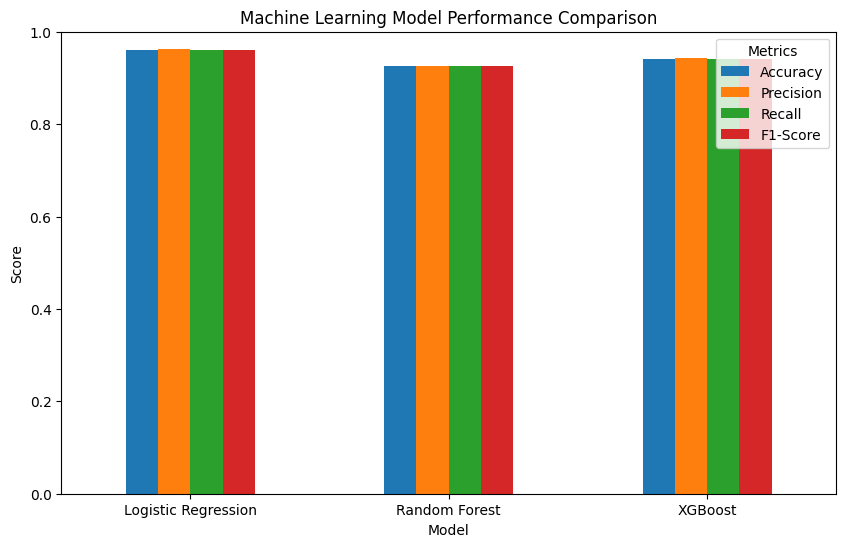

In [33]:
plt.figure(figsize=(10, 6))

results_plot = results.set_index("Model")[
    ["Accuracy", "Precision", "Recall", "F1-Score"]
]

results_plot.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Machine Learning Model Performance Comparison")
plt.xlabel("Model")
plt.ylabel("Score")
plt.ylim(0, 1)

plt.xticks(rotation=0)
plt.legend(title="Metrics")

plt.show()

In [34]:
print("===== LOGISTIC REGRESSION CLASSIFICATION REPORT =====")

print(
    classification_report(
        y_test_model,
        logistic_pred,
        target_names=activity_labels["Activity_Name"]
    )
)

===== LOGISTIC REGRESSION CLASSIFICATION REPORT =====
                    precision    recall  f1-score   support

           WALKING       0.95      0.99      0.97       496
  WALKING_UPSTAIRS       0.97      0.94      0.96       471
WALKING_DOWNSTAIRS       0.99      0.96      0.98       420
           SITTING       0.98      0.88      0.92       491
          STANDING       0.90      0.98      0.94       532
            LAYING       1.00      1.00      1.00       537

          accuracy                           0.96      2947
         macro avg       0.96      0.96      0.96      2947
      weighted avg       0.96      0.96      0.96      2947



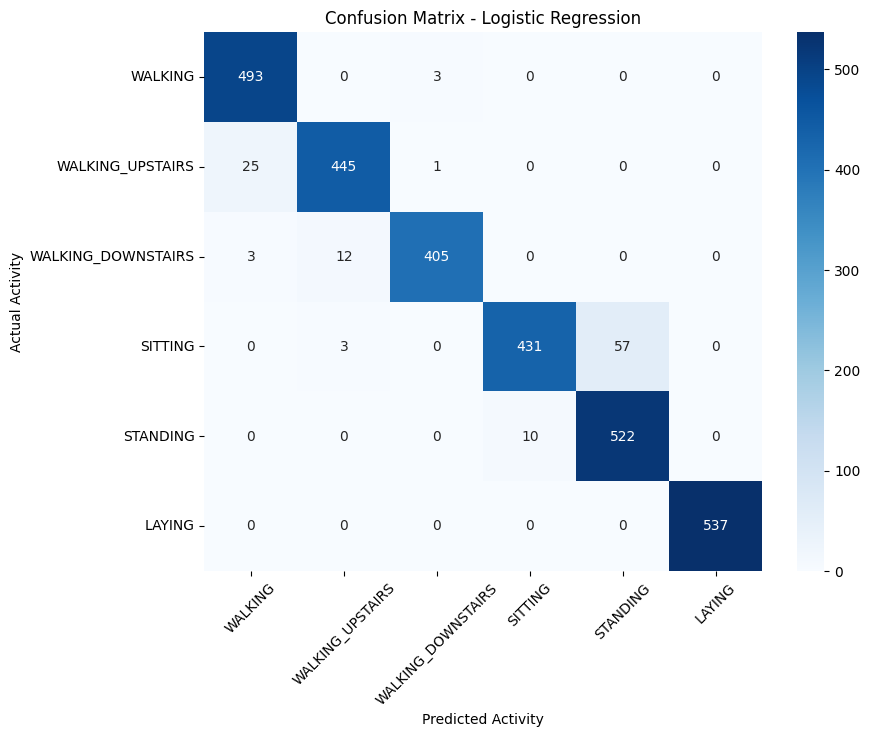

In [35]:
cm = confusion_matrix(
    y_test_model,
    logistic_pred
)

plt.figure(figsize=(9, 7))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=activity_labels["Activity_Name"],
    yticklabels=activity_labels["Activity_Name"]
)

plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted Activity")
plt.ylabel("Actual Activity")

plt.xticks(rotation=45)
plt.yticks(rotation=0)

plt.show()

In [36]:
# Calculate feature importance using Logistic Regression coefficients

importance = np.mean(
    np.abs(logistic_model.coef_),
    axis=0
)

feature_importance = pd.DataFrame({
    "Feature": X_train_final.columns,
    "Importance": importance
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print("Top 20 Important Features:")

feature_importance.head(20)

Top 20 Important Features:


,Feature,Importance
182,tBodyGyroJerk-entropy()-X,1.378415
41,tGravityAcc-mean()-Y,0.934234
50,tGravityAcc-max()-Y,0.893693
53,tGravityAcc-min()-Y,0.884957
445,fBodyGyro-entropy()-X,0.787757
56,tGravityAcc-energy()-X,0.753908
37,"tBodyAcc-correlation()-X,Y",0.735053
186,"tBodyGyroJerk-arCoeff()-X,2",0.714890
104,tBodyAccJerk-entropy()-Z,0.661553
118,"tBodyAccJerk-correlation()-X,Z",0.651661


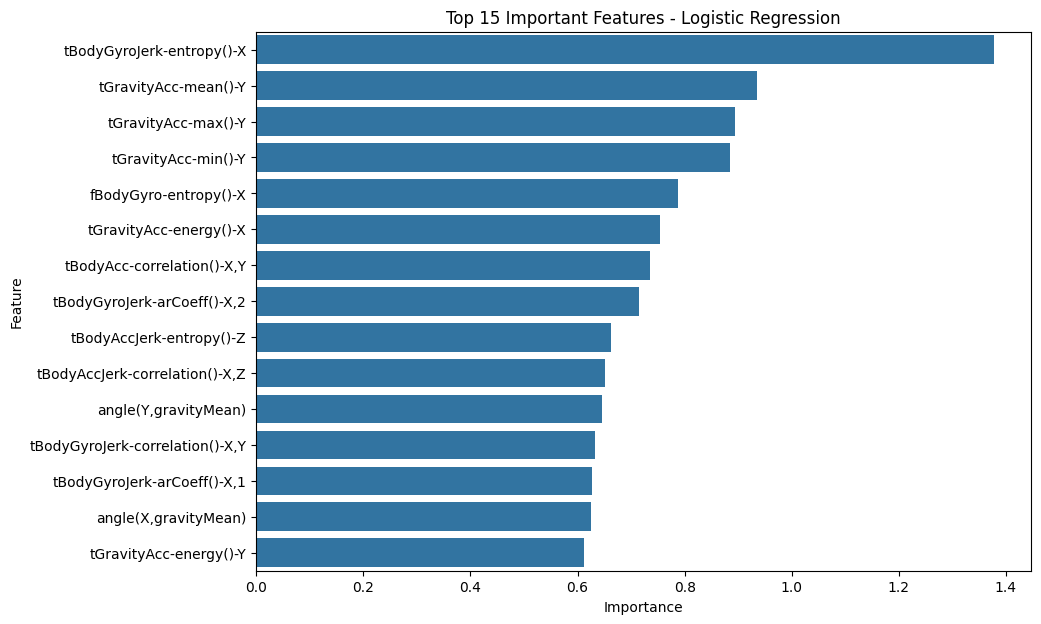

In [37]:
top_features = feature_importance.head(15)

plt.figure(figsize=(10, 7))

sns.barplot(
    data=top_features,
    x="Importance",
    y="Feature"
)

plt.title("Top 15 Important Features - Logistic Regression")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.show()

In [38]:
import joblib

model_path = "human_activity_logistic_regression_model.pkl"

joblib.dump(
    logistic_model,
    model_path
)

print("Model saved successfully!")
print("File:", model_path)

Model saved successfully!
File: human_activity_logistic_regression_model.pkl


In [39]:
feature_names = list(X_train_final.columns)

joblib.dump(
    feature_names,
    "human_activity_feature_names.pkl"
)

print("Feature names saved successfully!")

Feature names saved successfully!


In [40]:
loaded_model = joblib.load(
    "human_activity_logistic_regression_model.pkl"
)

test_prediction = loaded_model.predict(
    X_test_final.iloc[[0]]
)

predicted_activity = activity_map[test_prediction[0]]

print("Predicted Activity:", predicted_activity)
print(
    "Actual Activity:",
    activity_map[y_test_model.iloc[0]]
)

Predicted Activity: STANDING
Actual Activity: STANDING


## Final Model Summary

This project developed a Human Activity Recognition system using smartphone sensor data. The dataset contains 10,299 observations and 561 original sensor-derived features representing six different physical activities. Data preprocessing included checking missing values, infinite values, duplicate rows, and feature quality. Two additional engineered features, sensor mean and sensor standard deviation, were created to capture overall sensor behavior.

Three machine learning models were trained and compared: Logistic Regression, Random Forest, and XGBoost. Logistic Regression achieved the best overall performance with an accuracy of 96.13% and an F1-score of 96.12%. Random Forest achieved 92.53% accuracy, while XGBoost achieved 94.20% accuracy.

Based on the evaluation results, Logistic Regression was selected as the final model. The trained model was saved using Joblib and can be integrated into a Streamlit application for real-time human activity prediction.